In [3]:
import numpy as np
import pandas as pd

In [6]:
df = pd.DataFrame({'Имя': ['name_1', 'name_2', 'name_3', 'name_3', 'name_3', 'name_2', 'name_4'],
                  'Город Работы': ['city_1', 'city_2', 'city_3', 'city_3', 'city_4', 'city_1', np.nan],
                  'Как_долго_работал': [12, 24, 36, 12, 48, 5, np.nan]}
                 )
df

,Имя,Город Работы,Как_долго_работал
0,name_1,city_1,12.0
1,name_2,city_2,24.0
2,name_3,city_3,36.0
3,name_3,city_3,12.0
4,name_3,city_4,48.0
5,name_2,city_1,5.0
6,name_4,NaN,NaN


In [12]:
groups = df.groupby('Имя')

In [14]:
for name, group in groups:
    print(name)
    print(group, end='\n\n')

name_1
      Имя Город Работы  Как_долго_работал
0  name_1       city_1               12.0

name_2
      Имя Город Работы  Как_долго_работал
1  name_2       city_2               24.0
5  name_2       city_1                5.0

name_3
      Имя Город Работы  Как_долго_работал
2  name_3       city_3               36.0
3  name_3       city_3               12.0
4  name_3       city_4               48.0

name_4
      Имя Город Работы  Как_долго_работал
6  name_4          NaN                NaN



In [17]:
groups = df.groupby(['Имя', 'Город Работы'])

In [19]:
for name, group in groups:
    print(name)
    print(group, end='\n\n')

('name_1', 'city_1')
      Имя Город Работы  Как_долго_работал
0  name_1       city_1               12.0

('name_2', 'city_1')
      Имя Город Работы  Как_долго_работал
5  name_2       city_1                5.0

('name_2', 'city_2')
      Имя Город Работы  Как_долго_работал
1  name_2       city_2               24.0

('name_3', 'city_3')
      Имя Город Работы  Как_долго_работал
2  name_3       city_3               36.0
3  name_3       city_3               12.0

('name_3', 'city_4')
      Имя Город Работы  Как_долго_работал
4  name_3       city_4               48.0



In [23]:
df.groupby('Город Работы').sum()

,Имя,Как_долго_работал
Город Работы,,
city_1,name_1name_2,17.0
city_2,name_2,24.0
city_3,name_3name_3,48.0
city_4,name_3,48.0


In [25]:
df.groupby('Город Работы', dropna= False).sum()

,Имя,Как_долго_работал
Город Работы,,
city_1,name_1name_2,17.0
city_2,name_2,24.0
city_3,name_3name_3,48.0
city_4,name_3,48.0
NaN,name_4,0.0


In [27]:
df.groupby('Имя').sum()

,Город Работы,Как_долго_работал
Имя,,
name_1,city_1,12.0
name_2,city_2city_1,29.0
name_3,city_3city_3city_4,96.0
name_4,0,0.0


In [29]:
df.groupby('Имя', as_index=False).sum()

,Имя,Город Работы,Как_долго_работал
0,name_1,city_1,12.0
1,name_2,city_2city_1,29.0
2,name_3,city_3city_3city_4,96.0
3,name_4,0,0.0


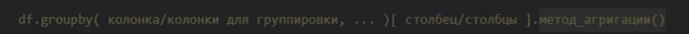

In [32]:
df

,Имя,Город Работы,Как_долго_работал
0,name_1,city_1,12.0
1,name_2,city_2,24.0
2,name_3,city_3,36.0
3,name_3,city_3,12.0
4,name_3,city_4,48.0
5,name_2,city_1,5.0
6,name_4,NaN,NaN


In [34]:
df.groupby('Имя')['Как_долго_работал'].sum()

Имя
name_1    12.0
name_2    29.0
name_3    96.0
name_4     0.0
Name: Как_долго_работал, dtype: float64

In [48]:
df.groupby( ['Имя', 'Город Работы'] ).count()

Как_долго_работал
Имя    Город Работы                   
name_1 city_1                        1
name_2 city_1                        1
       city_2                        1
name_3 city_3                        2
       city_4                        1

In [52]:
df.groupby( ['Имя', 'Город Работы'], dropna=False ).count().rename(columns={'Как_долго_работал': 'count'})

count
Имя    Город Работы       
name_1 city_1            1
name_2 city_1            1
       city_2            1
name_3 city_3            2
       city_4            1
name_4 NaN               0

In [58]:
df.groupby('Имя')['Город Работы'].nunique()

Имя
name_1    1
name_2    2
name_3    2
name_4    0
Name: Город Работы, dtype: int64

In [61]:
df.groupby('Имя').agg({'Как_долго_работал': 'sum'})

,Как_долго_работал
Имя,
name_1,12.0
name_2,29.0
name_3,96.0
name_4,0.0


In [63]:
df.groupby('Имя').agg({'Город Работы': 'count',
                       'Как_долго_работал': ['sum','max']}
                     )

Город Работы Как_долго_работал      
              count               sum   max
Имя                                        
name_1            1              12.0  12.0
name_2            2              29.0  24.0
name_3            3              96.0  48.0
name_4            0               0.0   NaN

In [69]:
df.groupby('Имя').agg( count_jobs = ('Город Работы', 'count'),
                       exp = ('Как_долго_работал', 'sum'),
                       max_time_work = ('Как_долго_работал', 'max')
)

,count_jobs,exp,max_time_work
Имя,,,
name_1,1,12.0,12.0
name_2,2,29.0,24.0
name_3,3,96.0,48.0
name_4,0,0.0,NaN
